Генерация очков за прошлый сезон

In [ ]:
# import numpy as np
# import pandas as pd

# sigma_log = 0.5

# players_num = 2000

# np.random.seed(124)

# points = pd.DataFrame(6 * np.random.lognormal(mean = 1.2, sigma = sigma_log, size = 2000), columns=['points_num'])

# points['points_num'] = points['points_num'].round(0)

# points.head(10)

In [ ]:
# group = points.groupby('points_num')['points_num'].count()
# group

In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(group.index, group.values)

Генерация показателя полезности за прошлый сезон

In [ ]:
# mu = 0
# sigma = 6

# np.random.seed(124)

# plus_minus = pd.DataFrame(np.random.normal(loc=mu, scale = sigma, size = players_num), columns = ['plus/minus'])

In [ ]:
# plus_minus['plus/minus'] = plus_minus['plus/minus'].round(0)

In [ ]:
# group = plus_minus.groupby('plus/minus')['plus/minus'].count()
# group

In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(group.index, group.values)

Генерация позиции полевого игрока

In [ ]:
# defense_proportion = 0.4

# np.random.seed(124)

# position = pd.DataFrame(np.random.binomial(n = 1, p = defense_proportion, size = players_num), columns= ['is_defenseman'])

In [ ]:
# group = position.groupby('is_defenseman')['is_defenseman'].count()
# group

In [ ]:
# df_pre = pd.merge(position, points, left_index = True, right_index = True, how = 'inner')

# df_previous = pd.merge(df_pre, plus_minus, left_index = True, right_index = True, how = 'inner')

Генерация количества проведенных сезонов на профессиональном уровне

In [ ]:
# np.random.seed(124)

# age = pd.DataFrame(np.random.normal(loc = 10, scale = 2.5, size = players_num), columns = ['seasons'])

# age['seasons'] = age['seasons'].round()


In [ ]:
# df_previous = pd.merge(df, age, left_index = True, right_index = True, how = 'inner')

Вот здесь начинается ДЗ

Считываем реальные данные

In [ ]:
import pandas as pd

example = pd.read_excel('Данные для копулуса.xlsx', sheet_name = 'Игроки', names = ['points', 'plus/minus', 'PIM', 'is_defenseman', 'GP'])

Скачиваем библиотеку для генерации синтетических данных на основе реальных

In [ ]:
!pip install copulas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.6 MB/s eta 0:00:00


Обучаем и генерируем данные, зафиксировав сид для воспроизводимости (здесь грузит секунд 20)

In [ ]:
from copulas.multivariate import GaussianMultivariate

copula = GaussianMultivariate()
copula.fit(example)

copula.set_random_state(42)

players_num = 2000

synthetic_data = copula.sample(players_num)

In [ ]:
synthetic_data.head()

,points,plus/minus,PIM,is_defenseman,GP
0,1.449866,-3.822793,19.963613,0.141345,14.778531
1,22.776242,-8.702476,12.074262,-0.123793,52.646919
2,13.283416,-0.532247,7.927048,0.902244,68.378467
3,11.910479,0.724082,17.156017,1.022475,65.704632
4,-1.605504,-3.881968,-3.842505,0.856205,12.923317


Обрабатываем сгенерированные данные, чтобы не было 85.5 очков и тд.

In [ ]:
def gp_fix(x, data):
  if x < 0:
    return data['GP'].quantile(0.10)
  else:
    return min(max(1, round(x, 0)), 68)

def points_fix(x):
  if x > 0:
    return round(x, 0)
  else:
    return 0

def pim_fix(x):
  if x > 0:
    return round(x, 0)
  else:
    return 0

def is_defenseman_fix(x):
  if x > 0:
    return round(x, 0)
  else:
    return 0

In [ ]:
synthetic_data['points'] = synthetic_data['points'].apply(lambda x: points_fix(x))
synthetic_data['PIM'] = synthetic_data['PIM'].apply(lambda x: pim_fix(x))
synthetic_data['plus/minus'] = synthetic_data['plus/minus'].round(0)
synthetic_data['is_defenseman'] = synthetic_data['is_defenseman'].apply(lambda x: is_defenseman_fix(x))
synthetic_data['GP'] = synthetic_data['GP'].apply(lambda x: gp_fix(x, synthetic_data))

Сделаем другой датасет, чтобы название было короче, и сделаем еще одну обработку (игрок физически вряд ли сможет иметь полезность больше 40 и меньше -40 за сезон)

In [ ]:
df = synthetic_data
df['plus/minus'] = df['plus/minus'].apply(lambda x: max(min(x, 40), -40))
df['GP'] = round(df['GP'], 0)

Генерируем ненаблюдаемую переменную (random_seed везде дальше разные, подбирали, чтобы данные были нормальные)

In [ ]:
import numpy as np

np.random.seed(31)

from scipy.stats import t, chi2, f, norm, lognorm, poisson, binom, uniform, expon, logistic, beta

no_puck_talent = beta.rvs(size = players_num, a = 2, b = 5, random_state = 100)

no_puck_talent = (no_puck_talent) * 99 + 1

no_puck_talent = np.round(no_puck_talent)

non_vision = pd.DataFrame(no_puck_talent, columns= ['no_puck_talent'])

In [ ]:
df = pd.merge(df, non_vision, left_index = True, right_index = True, how = 'inner')

df.head()

,points,plus/minus,PIM,is_defenseman,GP,no_puck_talent
0,1.0,-4.0,20.0,0.0,15.0,6.0
1,23.0,-9.0,12.0,0.0,53.0,37.0
2,13.0,-1.0,8.0,1.0,68.0,22.0
3,12.0,1.0,17.0,1.0,66.0,18.0
4,0.0,-4.0,0.0,1.0,13.0,38.0


Генерируем инструментальную переменную

In [ ]:
import math

df['is_legioner_index'] = (((df['points'] / df['GP']) / (1 - df['is_defenseman']/3))/2 + 0.01 * (df['plus/minus'] * df['PIM'])) - 1.5

In [ ]:
df['is_legioner_prob'] = 1 / (1 + np.exp(-df['is_legioner_index']))

In [ ]:
np.random.seed(124)

df['is_legioner'] = np.random.binomial(n = 1, p = df['is_legioner_prob'], size = 2000)

In [ ]:
df.is_legioner.sum()

np.int64(516)

Генерируем переменную воздействия

In [ ]:
df['nhl_exp_index'] = (75 * np.sqrt(df['no_puck_talent']) + 145 * ((df['points'] / df['GP']) / (1 - df['is_defenseman']/3)) + 2 * df['plus/minus'] - 2 * (df['PIM'] / df['GP']) - 520)/100

# df['nhl_exp_index'] = (np.square(df['no_puck_talent']/20) + 120 * ((df['points'] / df['GP']) / (1 - df['is_defenseman']/3)) + 2 * df['plus/minus'] - 2 * (df['PIM'] / df['GP']) - 520)/100

In [ ]:
np.random.seed(124)

df['legioner_1'] = 1

df['legioner_0'] = 0

df['nhl1_index'] = df['nhl_exp_index'] + 1.3 * df['legioner_1']

df['nhl0_index'] = df['nhl_exp_index'] + 1.3 * df['legioner_0']

df['nhl1_prob'] = norm.cdf(df['nhl1_index'])
df['nhl0_prob'] = norm.cdf(df['nhl0_index'])

In [ ]:
np.random.seed(67)

df['u'] = np.random.uniform(0,1, size = 2000)

In [ ]:
df['nhl_exp1'] = df['nhl1_prob'] > df['u']
df['nhl_exp0'] = df['nhl0_prob'] > df['u']

In [ ]:
def player_type(one, zero):
  if one == 1 and zero == 1:
    return 'always_nhl_player'
  elif one == 0 and zero == 0:
    return 'never_nhl_player'
  elif one == 1  and zero == 0:
    return 'only_if_legioner_nhl_player'
  elif one == 0 and zero == 1:
    return 'only_russian_nhl_player'

df['player_type'] = df.apply(lambda x: player_type(x['nhl_exp1'], x['nhl_exp0']), axis = 1)

In [ ]:
df['nhl_exp'] = df['nhl_exp1'] * df['is_legioner'] + df['nhl_exp0'] * (1 - df['is_legioner'])

Проверим сколько получилось хоккеистов, игравших в НХЛ

In [ ]:
df['nhl_exp'].sum()

np.int64(797)

Генерируем целевую переменную

In [ ]:
np.random.seed(124)

df['errors0'] = np.random.normal(loc=5, scale = 6, size = players_num)
df['errors1'] = np.random.normal(loc=4, scale=6, size = players_num)

In [ ]:
df['g0_obs']   = (np.minimum(df['points'] / df['GP'] * 15, 30) + 0.3 * df['GP'] + np.sign(df['plus/minus']) * (df['plus/minus'] ** 2) / 120 * (1+df['is_defenseman']) - 0.1 * df['PIM'])

df['g0_unobs'] =  0.35 * df['no_puck_talent']
df['g0'] = df['g0_obs'] + df['g0_unobs']

df['g1_obs']   = (np.minimum(df['points'] / df['GP'] * 15, 32) + 0.3 * df['GP'] + np.sign(df['plus/minus']) * (df['plus/minus'] ** 2) / 120 * (1+df['is_defenseman']) - 0.05 * df['PIM'])
df['g1_unobs'] =  0.4 * df['no_puck_talent']
df['g1'] = df['g1_obs'] + df['g1_unobs']


df['wage0'] = df['g0'] + df['errors0']
df['wage1'] = df['g1'] + df['errors1']


df['annual_contract'] = round(df['wage1'] * df['nhl_exp'] + df['wage0'] * (1 - df['nhl_exp']), 0)

df['annual_contract'] = df['annual_contract'].apply(lambda x: max(min(100, x), 3))

Проверяем дисперсии

In [ ]:
print(pd.DataFrame(data    = [np.var(df.errors0),   np.var(df.g0),
                              np.var(df.g0_obs),   np.var(df.g0_unobs),
                              np.var(df.errors1),   np.var(df.g1),
                              np.var(df.g1_obs),   np.var(df.g1_unobs)],
                   index   = ['Var(eps0)',     'Var(g0)',
                              'Var(g0_obs)',   'Var(g0_unobs)',
                              'Var(eps1)',     'Var(g1)',
                              'Var(g1_obs)',   'Var(g1_unobs)'],
                   columns = ['Оценка']))

                   Оценка
Var(eps0)       36.156836
Var(g0)        115.839891
Var(g0_obs)     83.502877
Var(g0_unobs)   29.341381
Var(eps1)       34.469184
Var(g1)        132.435357
Var(g1_obs)     90.786063
Var(g1_unobs)   38.323436


Убираем ненужные переменные и сохраняем в финальный датасет

In [ ]:
final_df = df[['points', 'plus/minus', 'PIM', 'is_defenseman', 'GP', 'is_legioner', 'nhl_exp', 'annual_contract']]
final_df.head()

,points,plus/minus,PIM,is_defenseman,GP,is_legioner,nhl_exp,annual_contract
0,1.0,-4.0,20.0,0.0,15.0,0,0,12.0
1,23.0,-9.0,12.0,0.0,53.0,0,0,36.0
2,13.0,-1.0,8.0,1.0,68.0,0,0,27.0
3,12.0,1.0,17.0,1.0,66.0,0,0,46.0
4,0.0,-4.0,0.0,1.0,13.0,0,1,30.0


Посмотрим на распреления переменных

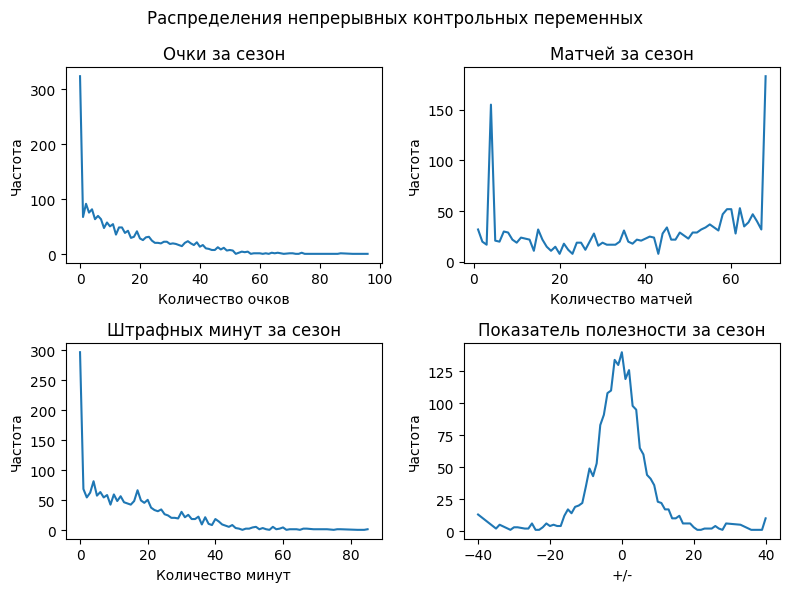

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.subplot(2,2,1)

plt.suptitle('Распределения непрерывных контрольных переменных')

group_points = final_df.groupby('points')['points'].count()
plt.plot(group_points.index, group_points.values)
plt.title('Очки за сезон')
plt.xlabel('Количество очков')
plt.ylabel('Частота')


plt.subplot(2,2,2)
group_gp = final_df.groupby('GP')['GP'].count()
plt.plot(group_gp.index, group_gp.values)
plt.title('Матчей за сезон')
plt.xlabel('Количество матчей')
plt.ylabel('Частота')

plt.subplot(2,2,3)
group_pim = final_df.groupby('PIM')['PIM'].count()
plt.plot(group_pim.index, group_pim.values)
plt.title('Штрафных минут за сезон')
plt.xlabel('Количество минут')
plt.ylabel('Частота')

plt.subplot(2,2,4)
group_pm = final_df.groupby('plus/minus')['PIM'].count()
plt.plot(group_pm.index, group_pm.values)
plt.title('Показатель полезности за сезон')
plt.xlabel('+/-')
plt.ylabel('Частота')


plt.tight_layout()
plt.show()

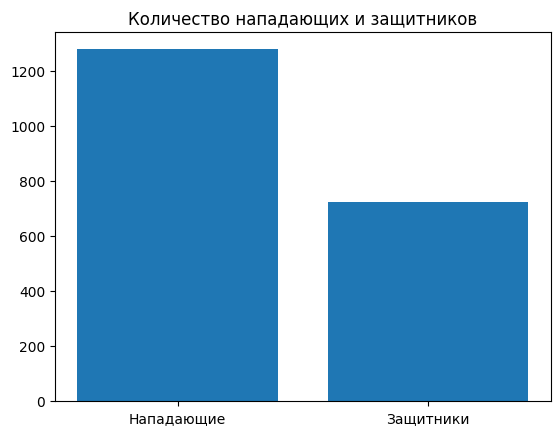

In [ ]:
group_defense = pd.DataFrame(final_df.groupby('is_defenseman')['GP'].count())

group_defense['types'] = ['Нападающие', 'Защитники']

plt.title('Количество нападающих и защитников')

plt.bar(group_defense.types, group_defense.GP)

plt.show()

Разбиение по типам игроков

In [ ]:
df.groupby('player_type')['PIM'].count()

,PIM
player_type,
always_nhl_player,642
never_nhl_player,753
only_if_legioner_nhl_player,605


Корреляционная матрица

In [ ]:
df.select_dtypes('number')[['points', 'plus/minus', 'PIM', 'is_defenseman', 'GP',
                            'no_puck_talent', 'is_legioner', 'nhl_exp', 'annual_contract']].corr()

,points,plus/minus,PIM,is_defenseman,GP,no_puck_talent,is_legioner,nhl_exp,annual_contract
points,1.000000,0.250332,0.627576,-0.157019,0.715585,0.006283,0.225556,0.207276,0.610053
plus/minus,0.250332,1.000000,0.100744,0.021693,0.143078,0.035731,0.364575,0.237892,0.351777
PIM,0.627576,0.100744,1.000000,0.046846,0.602841,-0.006526,0.189250,0.138522,0.365464
is_defenseman,-0.157019,0.021693,0.046846,1.000000,-0.035964,0.018404,0.011240,0.006981,-0.071741
GP,0.715585,0.143078,0.602841,-0.035964,1.000000,0.018760,0.138412,0.089618,0.577595
no_puck_talent,0.006283,0.035731,-0.006526,0.018404,0.018760,1.000000,0.019753,0.555472,0.501596
is_legioner,0.225556,0.364575,0.189250,0.011240,0.138412,0.019753,1.000000,0.372001,0.207958
nhl_exp,0.207276,0.237892,0.138522,0.006981,0.089618,0.555472,0.372001,1.000000,0.470264
annual_contract,0.610053,0.351777,0.365464,-0.071741,0.577595,0.501596,0.207958,0.470264,1.000000


Описательные статистики

In [ ]:
df[['points', 'plus/minus', 'PIM', 'GP',
                            'no_puck_talent', 'annual_contract']].agg(['mean', 'std', 'median', 'min', 'max', ])

,points,plus/minus,PIM,GP,no_puck_talent,annual_contract
mean,15.573500,-0.545500,15.6015,39.205500,28.718000,31.665500
std,16.095438,9.256931,14.8197,22.594524,15.480352,12.678406
median,11.000000,-1.000000,12.0000,44.000000,27.000000,31.000000
min,0.000000,-40.000000,0.0000,1.000000,1.000000,3.000000
max,96.000000,40.000000,85.0000,68.000000,84.000000,71.000000


In [ ]:
df[['is_defenseman', 'is_legioner', 'nhl_exp']].agg(['sum', 'mean'])

,is_defenseman,is_legioner,nhl_exp
sum,722.000,516.000,797.0000
mean,0.361,0.258,0.3985


Разделяем выборку на тестовую и тренеровочную

In [ ]:
from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(final_df[['points', 'plus/minus', 'PIM', 'is_defenseman', 'GP',
                      'is_legioner', 'nhl_exp']], final_df['annual_contract'], test_size = 0.25, random_state = 42)

In [ ]:
X_train.shape

(1500, 7)

# Классификация

Отбираем признаки

In [ ]:
regressors = ['points', 'GP', 'plus/minus', 'is_legioner']

In [ ]:
X_train_knn = X_train[regressors].copy()
x_test_knn = x_test[regressors].copy()
Y_train_knn = X_train['nhl_exp'].copy()
y_test_knn = x_test['nhl_exp'].copy()

### Метод ближайших соседей

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X_train_knn = X_train_knn.reset_index(drop = True)
Y_train_knn = Y_train_knn.reset_index(drop = True)
x_test_knn = x_test_knn.reset_index(drop = True)
y_test_knn = y_test_knn.reset_index(drop = True)

Нормализуем данные

In [ ]:
import sklearn

X_train_knn_initial = X_train_knn.copy()
x_test_knn_initial  = x_test_knn.copy()

scaler = sklearn.preprocessing.StandardScaler().set_output(transform = "pandas").fit(X_train_knn)

X_train_knn = scaler.transform(X_train_knn_initial)
x_test_knn  = scaler.transform(x_test_knn_initial)

Обучаем модель

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 10,
                           metric = "minkowski"
                           , p = 2
                           )
knn.fit(X_train_knn, Y_train_knn)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
predictions_train_knn = knn.predict(X_train_knn)

predictions_test_knn = knn.predict(x_test_knn)

In [ ]:
from sklearn.metrics import accuracy_score

print(f'Точность на обучающей выборке: {accuracy_score(predictions_train_knn, Y_train_knn)}\n'
      f'Точность на тестовой выборке: {accuracy_score(predictions_test_knn, y_test_knn)}')

Точность на обучающей выборке: 0.7466666666666667
Точность на тестовой выборке: 0.678


Используем кроссвалидацию

Определим для всех моделей фолды для воспроизводимости

In [ ]:
from sklearn.model_selection import KFold

cv_fix = KFold(n_splits = 5, shuffle = True, random_state = 1705)

In [ ]:
from sklearn.model_selection import cross_val_score

accuracy_cv = cross_val_score(knn, X_train_knn, Y_train_knn, cv=cv_fix, scoring = 'accuracy').mean()

print(f'Точность на кросс-валидации: {accuracy_cv}')

Точность на кросс-валидации: 0.6946666666666667


Подбираем параметры

In [ ]:
from sklearn.model_selection import GridSearchCV

hyperparameters_knn = {'n_neighbors': [4, 6, 8, 10, 12, 20, 30, 40, 50, 100, 150, 200, 250], 'p': [1, 2, 3]}

GSCV_knn = GridSearchCV(estimator = knn,
                        param_grid = hyperparameters_knn,
                        scoring = "accuracy",
                        cv = cv_fix)
GSCV_knn.fit(X_train_knn, Y_train_knn)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=KNeighborsClassifier(n_neighbors=10),
             param_grid={'n_neighbors': [4, 6, 8, 10, 12, 20, 30, 40, 50, 100,
                                         150, 200, 250],
                         'p': [1, 2, 3]},
             scoring='accuracy')

In [ ]:
GSCV_knn.best_params_

{'n_neighbors': 40, 'p': 3}

In [ ]:
knn2 = KNeighborsClassifier(n_neighbors = GSCV_knn.best_params_['n_neighbors'],
                            metric = "minkowski",
                            p = GSCV_knn.best_params_["p"])
knn2.fit(X_train_knn, Y_train_knn)

KNeighborsClassifier(n_neighbors=40, p=3)

In [ ]:
predictions_train_knn2 = knn2.predict(X_train_knn)

predictions_test_knn2 = knn2.predict(x_test_knn)

accuracy_knn2_train = accuracy_score(predictions_train_knn2, Y_train_knn)
accuracy_knn2_test  = accuracy_score(predictions_test_knn2, y_test_knn)

print(f'Точность на обучающей выборке после тюнинга: {accuracy_knn2_train}\n'
      f'Точность на тестовой выборке после тюнинга: {accuracy_knn2_test}')

Точность на обучающей выборке после тюнинга: 0.7166666666666667
Точность на тестовой выборке после тюнинга: 0.696


In [ ]:
accuracy_cv_tuned = cross_val_score(knn2, X_train_knn, Y_train_knn, cv=cv_fix).mean()

print(f'Точность на кросс-валидации после тюнинга: {accuracy_cv_tuned}')

Точность на кросс-валидации после тюнинга: 0.7166666666666668


Используем F1

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

print(f'F1 на обучающей выборке: {f1_score(predictions_train_knn, Y_train_knn)}\n'
      f'F1 на тестовой выборке: {f1_score(predictions_test_knn, y_test_knn)}')

F1 на обучающей выборке: 0.6310679611650486
F1 на тестовой выборке: 0.5076452599388379


In [ ]:
f1_cv = cross_val_score(knn, X_train_knn, Y_train_knn, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации: {f1_cv}')

F1 на кросс-валидации: 0.5496207264612691


In [ ]:
hyperparameters_knn = {'n_neighbors': [4, 6, 8, 10, 12, 20, 30, 40, 50, 100, 150, 200, 250], 'p': [1, 2, 3]}

GSCV_knn_f1 = GridSearchCV(estimator  = knn,
                        param_grid = hyperparameters_knn,
                        scoring    = "f1",
                        cv         = cv_fix)
GSCV_knn_f1.fit(X_train_knn, Y_train_knn)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=KNeighborsClassifier(n_neighbors=10),
             param_grid={'n_neighbors': [4, 6, 8, 10, 12, 20, 30, 40, 50, 100,
                                         150, 200, 250],
                         'p': [1, 2, 3]},
             scoring='f1')

In [ ]:
GSCV_knn_f1.best_params_

{'n_neighbors': 30, 'p': 3}

In [ ]:
knnf1 = KNeighborsClassifier(n_neighbors = GSCV_knn_f1.best_params_['n_neighbors'],
                            metric = "minkowski",
                            p = GSCV_knn_f1.best_params_['p'])
knnf1.fit(X_train_knn, Y_train_knn)

KNeighborsClassifier(n_neighbors=30, p=3)

In [ ]:
predictions_train_knnf1 = knnf1.predict(X_train_knn)

predictions_test_knnf1 = knnf1.predict(x_test_knn)

f1_knnf1_train = f1_score(predictions_train_knnf1, Y_train_knn)
f1_knnf1_test  = f1_score(predictions_test_knnf1, y_test_knn)

print(f'Точность на обучающей выборке после тюнинга: {f1_knnf1_train}\n'
      f'Точность на тестовой выборке после тюнинга: {f1_knnf1_test}')

Точность на обучающей выборке после тюнинга: 0.5914396887159533
Точность на тестовой выборке после тюнинга: 0.5015673981191222


In [ ]:
f1_cv_tuned = cross_val_score(knnf1, X_train_knn, Y_train_knn, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации после тюнинга: {f1_cv_tuned}')

F1 на кросс-валидации после тюнинга: 0.5859881630733056


### Случайный лес

In [ ]:
X_train_rf = X_train[regressors].copy()
x_test_rf = x_test[regressors].copy()
Y_train_rf = X_train['nhl_exp'].copy()
y_test_rf = x_test['nhl_exp'].copy()

X_train_rf = X_train_rf.reset_index(drop = True)
Y_train_rf = Y_train_rf.reset_index(drop = True)
x_test_rf = x_test_rf.reset_index(drop = True)
y_test_rf = y_test_rf.reset_index(drop = True)

Обучаем рандомную модель

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth = 10,
                            max_features = 3,
                            max_samples = 300,
                            random_state = 777,
                            criterion = 'entropy')

rf.fit(X_train_rf, Y_train_rf)

prediction_rf_train = rf.predict(X_train_rf)

prediction_rf_test = rf.predict(x_test_rf)

print(f'Точность на обучающей выборке: {accuracy_score(prediction_rf_train, Y_train_rf)}\n'
      f'Точность на тестовой выборке: {accuracy_score(prediction_rf_test, y_test_rf)}')

Точность на обучающей выборке: 0.7606666666666667
Точность на тестовой выборке: 0.716


Используем кроссвалидацию

In [ ]:
accuracy_rf_cv = cross_val_score(rf, X_train_rf, Y_train_rf, cv=cv_fix, scoring = 'accuracy').mean()

print(f'Точность на кросс-валидации: {accuracy_rf_cv}')

Точность на кросс-валидации: 0.706


Подбираем параметры

In [ ]:
hyperparameters_rf = {'max_depth': [5,10,12,15,20], 'max_features': [2,3,4], 'max_samples': [300,500,1000]}

GSCV_rf = GridSearchCV(estimator = rf,
                        param_grid = hyperparameters_rf,
                        scoring = "accuracy",
                        cv = cv_fix
                      )
GSCV_rf.fit(X_train_rf, Y_train_rf)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=RandomForestClassifier(criterion='entropy', max_depth=10,
                                              max_features=3, max_samples=300,
                                              random_state=777),
             param_grid={'max_depth': [5, 10, 12, 15, 20],
                         'max_features': [2, 3, 4],
                         'max_samples': [300, 500, 1000]},
             scoring='accuracy')

In [ ]:
GSCV_rf.best_params_

{'max_depth': 5, 'max_features': 4, 'max_samples': 1000}

In [ ]:
rf2 = RandomForestClassifier(max_depth = GSCV_rf.best_params_['max_depth'],
                            max_features = GSCV_rf.best_params_['max_features'],
                            max_samples  = GSCV_rf.best_params_['max_samples'],
                            random_state = 777,
                            criterion = 'entropy')
rf2.fit(X_train_rf, Y_train_rf)

RandomForestClassifier(criterion='entropy', max_depth=5, max_features=4,
                       max_samples=1000, random_state=777)

In [ ]:
predictions_train_rf2 = rf2.predict(X_train_rf)

predictions_test_rf2 = rf2.predict(x_test_rf)

accuracy_rf2_train = accuracy_score(predictions_train_rf2, Y_train_rf)
accuracy_rf2_test  = accuracy_score(predictions_test_rf2, y_test_rf)

print(f'Точность на обучающей выборке после тюнинга: {accuracy_rf2_train}\n'
      f'Точность на тестовой выборке после тюнинга: {accuracy_rf2_test}')

Точность на обучающей выборке после тюнинга: 0.742
Точность на тестовой выборке после тюнинга: 0.704


In [ ]:
accuracy_rf_tuned = cross_val_score(rf2, X_train_rf, Y_train_rf, cv=cv_fix).mean()

print(f'Точность на кросс-валидации после тюнинга: {accuracy_rf_tuned}')

Точность на кросс-валидации после тюнинга: 0.7226666666666668


Пробуем критерий F1

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

print(f'F1 на обучающей выборке: {f1_score(prediction_rf_train, Y_train_rf)}\n'
      f'F1 на тестовой выборке: {f1_score(prediction_rf_test, y_test_rf)}')

F1 на обучающей выборке: 0.667900092506938
F1 на тестовой выборке: 0.5798816568047337


In [ ]:
f1_rf = cross_val_score(rf, X_train_rf, Y_train_rf, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации: {f1_rf}')

Подбираем гиперпараметры

In [ ]:
hyperparameters_rf = {'max_depth': [5,10,12,15,20], 'max_features': [2,3,4], 'max_samples': [300,500,1000]}

GSCV_rf_f1 = GridSearchCV(estimator  = rf,
                        param_grid = hyperparameters_rf,
                        scoring    = "f1",
                        cv         = cv_fix
                          )
GSCV_rf_f1.fit(X_train_rf, Y_train_rf)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=RandomForestClassifier(criterion='entropy', max_depth=10,
                                              max_features=3, max_samples=300,
                                              random_state=777),
             param_grid={'max_depth': [5, 10, 12, 15, 20],
                         'max_features': [2, 3, 4],
                         'max_samples': [300, 500, 1000]},
             scoring='f1')

In [ ]:
GSCV_rf_f1.best_params_

{'max_depth': 12, 'max_features': 2, 'max_samples': 300}

In [ ]:
rf_f1 = RandomForestClassifier(max_depth = GSCV_rf_f1.best_params_['max_depth'],
                            max_features = GSCV_rf_f1.best_params_['max_features'],
                            max_samples  = GSCV_rf_f1.best_params_['max_samples'],
                            random_state = 777,
                            criterion = 'entropy')
rf_f1.fit(X_train_rf, Y_train_rf)

RandomForestClassifier(criterion='entropy', max_depth=12, max_features=2,
                       max_samples=300, random_state=777)

In [ ]:
predictions_train_rf_f1 = rf_f1.predict(X_train_rf)

predictions_test_rf_f1 = rf_f1.predict(x_test_rf)

f1_rf_f1_train = f1_score(predictions_train_rf_f1, Y_train_rf)
f1_rf_f1_test  = f1_score(predictions_test_rf_f1, y_test_rf)

print(f'F1 на обучающей выборке после тюнинга: {f1_rf_f1_train}\n'
      f'F1 на тестовой выборке после тюнинга: {f1_rf_f1_test}')

F1 на обучающей выборке после тюнинга: 0.6855575868372943
F1 на тестовой выборке после тюнинга: 0.5545722713864307


In [ ]:
f1_rf_cv = cross_val_score(rf_f1, X_train_rf, Y_train_rf, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации после тюнинга: {f1_rf_cv}')

F1 на кросс-валидации после тюнинга: 0.6035012955975289


### Логистическая регрессия

По классике готовим данные

In [ ]:
X_train_lg = X_train[regressors].copy()
x_test_lg = x_test[regressors].copy()
Y_train_lg = X_train['nhl_exp'].copy()
y_test_lg = x_test['nhl_exp'].copy()

X_train_lg = X_train_rf.reset_index(drop = True)
Y_train_lg = Y_train_rf.reset_index(drop = True)
x_test_lg = x_test_rf.reset_index(drop = True)
y_test_lg = y_test_rf.reset_index(drop = True)

Обучаем случайную модель

In [ ]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(penalty = None, solver = 'lbfgs',
                           fit_intercept = True
                        , random_state = 42)

lg.fit(X_train_lg, Y_train_lg)

prediction_lg_train = lg.predict(X_train_lg)

prediction_lg_test = lg.predict(x_test_lg)

print(f'Точность на обучающей выборке: {accuracy_score(prediction_lg_train, Y_train_lg)}\n'
      f'Точность на тестовой выборке: {accuracy_score(prediction_lg_test, y_test_lg)}')

Точность на обучающей выборке: 0.716
Точность на тестовой выборке: 0.696


Смотрим точность на кросс-валидации

In [ ]:
accuracy_lg_cv = cross_val_score(lg, X_train_lg, Y_train_lg, cv=cv_fix, scoring = 'accuracy').mean()

print(f'Точность на кросс-валидации: {accuracy_lg_cv}')

Точность на кросс-валидации: 0.7153333333333334


Подбираем параметры (будет большой текст, который говорит о несовместимости некоторых параметров, но их такие комбинации просто скипнет)

In [ ]:
hyperparameters_lg = {'penalty': ['l1', 'l2', 'elasticnet', None],
                      'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
                      , 'fit_intercept': [True, False]}

GSCV_lg = GridSearchCV(estimator = lg,
                        param_grid = hyperparameters_lg,
                        scoring = "accuracy",
                        cv = cv_fix
                      )
GSCV_lg.fit(X_train_lg, Y_train_lg)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=LogisticRegression(penalty=None, random_state=42),
             param_grid={'fit_intercept': [True, False],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [ ]:
GSCV_lg.best_params_

{'fit_intercept': True, 'penalty': 'l1', 'solver': 'liblinear'}

Обучаем модель на подобранных гиперпараметрах

In [ ]:
lg2 = LogisticRegression(penalty = GSCV_lg.best_params_['penalty'], solver = GSCV_lg.best_params_['solver'],
                           fit_intercept = GSCV_lg.best_params_['fit_intercept']
                        , random_state = 42)

lg2.fit(X_train_lg, Y_train_lg)

prediction_lg2_train = lg2.predict(X_train_lg)

prediction_lg2_test = lg2.predict(x_test_lg)

print(f'Точность на обучающей выборке после тюнинга: {accuracy_score(prediction_lg2_train, Y_train_lg)}\n'
      f'Точность на тестовой выборке после тюнинга: {accuracy_score(prediction_lg2_test, y_test_lg)}')

Точность на обучающей выборке после тюнинга: 0.7146666666666667
Точность на тестовой выборке после тюнинга: 0.696


In [ ]:
accuracy_lg_tuned = cross_val_score(lg2, X_train_lg, Y_train_lg, cv=cv_fix).mean()

print(f'Точность на кросс-валидации после тюнинга: {accuracy_lg_tuned}')

Точность на кросс-валидации после тюнинга: 0.7153333333333334


Пробуем критерий F1

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

print(f'F1 на обучающей выборке: {f1_score(prediction_lg_train, Y_train_lg)}\n'
      f'F1 на тестовой выборке: {f1_score(prediction_lg_test, y_test_lg)}')

F1 на обучающей выборке: 0.585603112840467
F1 на тестовой выборке: 0.5128205128205128


In [ ]:
f1_lg = cross_val_score(lg, X_train_lg, Y_train_lg, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации: {f1_lg}')

F1 на кросс-валидации: 0.584443260106196


Подбираем гиперпараметры

In [ ]:
hyperparameters_lg = {'penalty': ['l1', 'l2', 'elasticnet', None],
                      'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
                      , 'fit_intercept': [True, False]}

GSCV_lg_f1 = GridSearchCV(estimator = lg,
                        param_grid = hyperparameters_lg,
                        scoring = "f1",
                        cv = cv_fix
                      )
GSCV_lg_f1.fit(X_train_lg, Y_train_lg)

GridSearchCV(cv=KFold(n_splits=5, random_state=1705, shuffle=True),
             estimator=LogisticRegression(penalty=None, random_state=42),
             param_grid={'fit_intercept': [True, False],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='f1')

In [ ]:
GSCV_lg_f1.best_params_

{'fit_intercept': False, 'penalty': 'l1', 'solver': 'liblinear'}

Обучаемся на лучших параметрах

In [ ]:
lg_f1 = LogisticRegression(penalty = GSCV_lg_f1.best_params_['penalty'], solver = GSCV_lg_f1.best_params_['solver'],
                           fit_intercept = GSCV_lg_f1.best_params_['fit_intercept']
                        , random_state = 42)

lg_f1.fit(X_train_lg, Y_train_lg)

prediction_lg_f1_train = lg_f1.predict(X_train_lg)

prediction_lg_f1_test = lg_f1.predict(x_test_lg)

print(f'F1 на обучающей выборке после тюнинга: {f1_score(prediction_lg_f1_train, Y_train_lg)}\n'
      f'F1 на тестовой выборке после тюнинга: {f1_score(prediction_lg_f1_test, y_test_lg)}')

F1 на обучающей выборке после тюнинга: 0.6018348623853211
F1 на тестовой выборке после тюнинга: 0.5585585585585585


In [ ]:
f1_lg_cv = cross_val_score(lg_f1, X_train_lg, Y_train_lg, cv=cv_fix, scoring = 'f1').mean()

print(f'F1 на кросс-валидации после тюнинга: {f1_lg_cv}')

F1 на кросс-валидации после тюнинга: 0.5999078853501688


### ROC-кривые

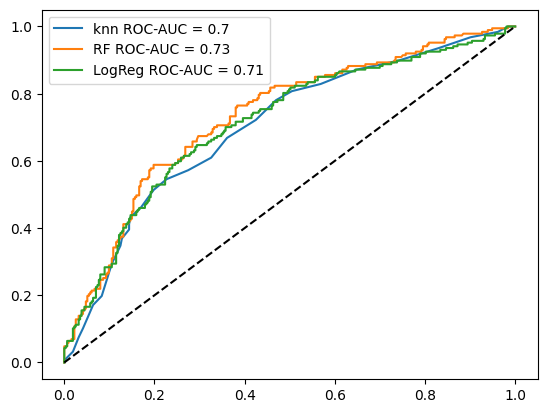

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_test_knn2_prob = knn2.predict_proba(x_test_knn)[:, 1]

fpr_knn2, tpr_knn2, thresholds_knn2 = roc_curve(y_test_knn, y_test_knn2_prob)
auc_knn2 = roc_auc_score(y_test_knn, y_test_knn2_prob)

y_test_rf2_prob = rf2.predict_proba(x_test_rf)[:, 1]

fpr_rf2, tpr_rf2, thresholds_rf2 = roc_curve(y_test_rf, y_test_rf2_prob)
auc_rf2 = roc_auc_score(y_test_rf, y_test_rf2_prob)

y_test_lg2_prob = lg2.predict_proba(x_test_lg)[:, 1]

fpr_lg2, tpr_lg2, thresholds_lg2 = roc_curve(y_test_lg, y_test_lg2_prob)
auc_lg2 = roc_auc_score(y_test_lg, y_test_lg2_prob)

plt.plot(fpr_knn2, tpr_knn2, label = f'knn ROC-AUC = {auc_knn2.round(2)}')
plt.plot(fpr_rf2, tpr_rf2, label = f'RF ROC-AUC = {auc_rf2.round(2)}')
plt.plot(fpr_lg2, tpr_lg2, label = f'LogReg ROC-AUC = {auc_lg2.round(2)}')
plt.plot([0, 1], [0, 1], 'k--')

plt.legend()
plt.show()

## Матрица ошибок на тестовой выборке для Случайного леса

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_test_rf, predictions_test_rf2)

array([[265,  48],
       [100,  87]])

Изобразим покрасивее, чтобы в отчет вставить

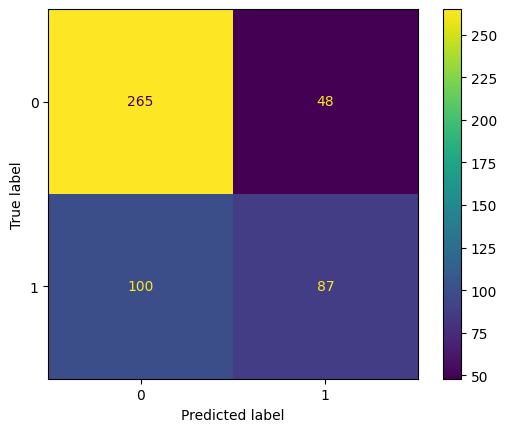

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_rf, predictions_test_rf2)
plt.show()

Смотрим другие пороги классификации

In [ ]:
probabilities = rf2.predict_proba(x_test_rf)[:, 1]

predictions_rf_4 = (probabilities >= 0.4).astype('int')

predictions_rf_6 = (probabilities >= 0.6).astype('int')

predictions_rf_7 = (probabilities >= 0.7).astype('int')

predictions_rf_8 = (probabilities >= 0.8).astype('int')

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

table = pd.DataFrame({'metric': ['accuracy', 'recall', 'precision']
                      , 'thresh_0.4': [accuracy_score(predictions_rf_4, y_test_rf), recall_score(y_test_rf, predictions_rf_4), precision_score(y_test_rf, predictions_rf_4)]
                      , 'thresh_0.6': [accuracy_score(predictions_rf_6, y_test_rf), recall_score(y_test_rf, predictions_rf_6), precision_score(y_test_rf, predictions_rf_6)]
                      , 'thresh_0.7': [accuracy_score(predictions_rf_7, y_test_rf), recall_score(y_test_rf, predictions_rf_7), precision_score(y_test_rf, predictions_rf_7)]
                      , 'thresh_0.8': [accuracy_score(predictions_rf_8, y_test_rf), recall_score(y_test_rf, predictions_rf_8), precision_score(y_test_rf, predictions_rf_8)]})
table

,metric,thresh_0.4,thresh_0.6,thresh_0.7,thresh_0.8
0,accuracy,0.694000,0.692000,0.676000,0.644000
1,recall,0.588235,0.395722,0.310160,0.085561
2,precision,0.591398,0.643478,0.637363,0.695652


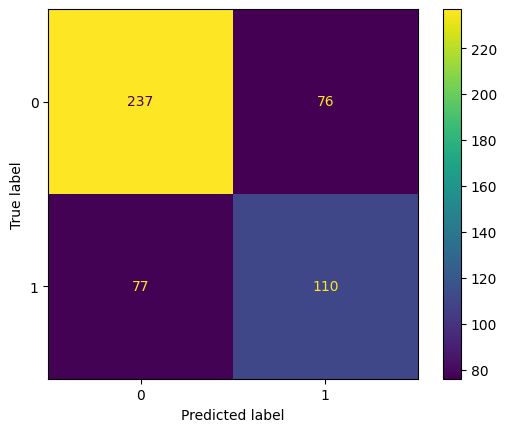

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_rf, predictions_rf_4)
plt.show()

## Считаем прибыль

TP = 20 (можем захантить игрока уровня НХЛ)

TN = 10 (можем справедливо рассчитать контракт игроку уровня КХЛ)

FP = -6 (переоценили игрока, спустя сезон поймем ошибку)

FN = -30 (недооценили игрока, ушел в другую команду или уехал в НХЛ)


In [ ]:
prices = pd.Series([20, 10, -6, -25], index = ["TP", "TN", "FP", "FN"])

Считаем оптимальный порог для knn

In [ ]:
prob_knn2_train = knn2.predict_proba(X_train_knn)[:, 1]

thresholds_knn2 = np.unique(np.sort(prob_knn2_train))

In [ ]:
n_threshold_knn2 = thresholds_knn2.size

profits_knn2 = np.zeros(n_threshold_knn2)

TP_vec = np.zeros(n_threshold_knn2)
TN_vec = np.zeros(n_threshold_knn2)
FP_vec = np.zeros(n_threshold_knn2)
FN_vec = np.zeros(n_threshold_knn2)

In [ ]:
for i in range(0, n_threshold_knn2):

  prediction_knn_i = (prob_knn2_train >= thresholds_knn2[i]).astype(int)

  TN_vec[i], FP_vec[i], FN_vec[i], TP_vec[i] = confusion_matrix(
    Y_train_knn, prediction_knn_i).ravel()

  predictions_knn_i = pd.Series([TP_vec[i], TN_vec[i], FP_vec[i], FN_vec[i]],
                                index = ["TP", "TN", "FP", "FN"])

  profits_knn2[i] = np.sum(prices * predictions_knn_i)

threshold_knn2 = thresholds_knn2[np.argmax(profits_knn2)]
print(f'Оптимальный порог: {threshold_knn2}, прибыль: {profits_knn2[np.argmax(profits_knn2)]}.')

Оптимальный порог: 0.275, прибыль: 9500.0.


Считаем оптимальный порог для случайного леса

In [ ]:
prob_rf2_train = rf2.predict_proba(X_train_rf)[:, 1]

thresholds_rf2 = np.unique(np.sort(prob_rf2_train))

In [ ]:
n_threshold_rf2 = thresholds_rf2.size

profits_rf2 = np.zeros(n_threshold_rf2)

TP_vec = np.zeros(n_threshold_rf2)
TN_vec = np.zeros(n_threshold_rf2)
FP_vec = np.zeros(n_threshold_rf2)
FN_vec = np.zeros(n_threshold_rf2)

In [ ]:
for i in range(0, n_threshold_rf2):

  prediction_rf_i = (prob_rf2_train >= thresholds_rf2[i]).astype(int)

  TN_vec[i], FP_vec[i], FN_vec[i], TP_vec[i] = confusion_matrix(
    Y_train_rf, prediction_rf_i).ravel()

  predictions_rf_i = pd.Series([TP_vec[i], TN_vec[i], FP_vec[i], FN_vec[i]],
                                index = ["TP", "TN", "FP", "FN"])

  profits_rf2[i] = np.sum(prices * predictions_rf_i)

threshold_rf2 = thresholds_rf2[np.argmax(profits_rf2)]
print(f'Оптимальный порог: {threshold_rf2}, прибыль: {profits_rf2[np.argmax(profits_rf2)]}.')

Оптимальный порог: 0.27750541018752745, прибыль: 10827.0.


Считаем оптимальный порог для логистической регрессии

In [ ]:
prob_lg2_train = lg2.predict_proba(X_train_lg)[:, 1]

thresholds_lg2 = np.unique(np.sort(prob_lg2_train))

In [ ]:
n_threshold_lg2 = thresholds_lg2.size

profits_lg2 = np.zeros(n_threshold_lg2)

TP_vec = np.zeros(n_threshold_lg2)
TN_vec = np.zeros(n_threshold_lg2)
FP_vec = np.zeros(n_threshold_lg2)
FN_vec = np.zeros(n_threshold_lg2)

In [ ]:
for i in range(0, n_threshold_lg2):

  prediction_lg_i = (prob_lg2_train >= thresholds_lg2[i]).astype(int)

  TN_vec[i], FP_vec[i], FN_vec[i], TP_vec[i] = confusion_matrix(
    Y_train_lg, prediction_lg_i).ravel()

  predictions_lg_i = pd.Series([TP_vec[i], TN_vec[i], FP_vec[i], FN_vec[i]],
                                index = ["TP", "TN", "FP", "FN"])

  profits_lg2[i] = np.sum(prices * predictions_lg_i)

threshold_lg2 = thresholds_lg2[np.argmax(profits_lg2)]
print(f'Оптимальный порог: {threshold_lg2}, прибыль: {profits_lg2[np.argmax(profits_lg2)]}.')

Оптимальный порог: 0.27271819973483225, прибыль: 9201.0.


Считаем прибыли на тестовой выборке для всех моделей

In [ ]:
pred_prob_knn2_test = knn2.predict_proba(x_test_knn)[:, 1]

predictions_knn2_test = (pred_prob_knn2_test >= threshold_knn2).astype('int')

TN_vec_knn, FP_vec_knn, FN_vec_knn, TP_vec_knn = confusion_matrix(
    y_test_knn, predictions_knn2_test).ravel()

predictions_knn2_test_final = pd.Series([TP_vec_knn, TN_vec_knn, FP_vec_knn, FN_vec_knn],
                                index = ["TP", "TN", "FP", "FN"])

profits_knn2_test = np.sum(prices * predictions_knn2_test_final)



pred_prob_rf2_test = rf2.predict_proba(x_test_rf)[:, 1]

predictions_rf2_test = (pred_prob_rf2_test >= threshold_rf2).astype('int')

TN_vec_rf, FP_vec_rf, FN_vec_rf, TP_vec_rf = confusion_matrix(
    y_test_rf, predictions_rf2_test).ravel()

predictions_rf2_test_final = pd.Series([TP_vec_rf, TN_vec_rf, FP_vec_rf, FN_vec_rf],
                                index = ["TP", "TN", "FP", "FN"])

profits_rf2_test = np.sum(prices * predictions_rf2_test_final)



pred_prob_lg2_test = lg2.predict_proba(x_test_lg)[:, 1]

predictions_lg2_test = (pred_prob_lg2_test >= threshold_lg2).astype('int')

TN_vec_lg, FP_vec_lg, FN_vec_lg, TP_vec_lg = confusion_matrix(
    y_test_lg, predictions_lg2_test).ravel()

predictions_lg2_test_final = pd.Series([TP_vec_lg, TN_vec_lg, FP_vec_lg, FN_vec_lg],
                                index = ["TP", "TN", "FP", "FN"])

profits_lg2_test = np.sum(prices * predictions_lg2_test_final)


print(f'Прибыль на тестовой выборке для knn: {profits_knn2_test}\n'
f'Прибыль на тестовой выборке для random forest: {profits_rf2_test}\n'
f'Прибыль на тестовой выборке для logreg: {profits_lg2_test}')

Прибыль на тестовой выборке для knn: 2582
Прибыль на тестовой выборке для random forest: 2723
Прибыль на тестовой выборке для logreg: 2609


In [ ]:
import pandas as pd
import numpy as np
import random
np.random.seed(67)
random.seed(67)
import bnlearn
import bnlearn as bn
import bnlearn as bn
df_train = pd.concat([X_train_knn, Y_train_knn], axis=1)
# 3. обучение структуры (оптимизация графа влияний)
model_structure = bn.structure_learning.fit(
    df_train_bn,
    methodtype='hc',   # hill-climbing
    scoretype='bic'    # оптимизация качества графа
)
# 4. превращаем в DAG
DAG = bn.make_DAG(model_structure)
# 5. визуализация ациклического ориентированного графа
bn.plot(DAG, interactive=False)

NameError: name 'df_train_bn' is not defined